In [6]:
from torch import nn
import torch
from torch.utils.data import Subset, Dataset, DataLoader, random_split
from torchvision import transforms, models
import torchvision
from PIL import Image
import os
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter
import lpips
import copy
from collections import defaultdict
import re
import json
import math
import open_clip

c:\Users\avmor\Desktop\обучение\CNN\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
class FlickrImg(Dataset):
 
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.paths = [
            os.path.join(image_dir, f)
            for f in os.listdir(image_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        self.transform = transform
 
    def __len__(self):
        return len(self.paths)
 
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img
 
def build_transforms(image_size=128):
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(image_size, scale=(0.85, 1.0), ratio=(0.95, 1.05)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),  # -> [-1, 1]
    ])
 
    val_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ])
 
    return train_transform, val_transform


In [8]:
dataset_path = 'data/Images'
train_transform, val_transform = build_transforms()
train_dataset = FlickrImg(dataset_path, transform=train_transform)
val_dataset = FlickrImg(dataset_path, transform=val_transform)

val_len = int(len(train_dataset) * 0.1)
train_len = len(train_dataset) - val_len

generator = torch.Generator().manual_seed(42)
train_indices, val_indices = random_split(range(len(train_dataset)), [train_len, val_len], generator=generator)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

train_loader = DataLoader(train_subset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

len(train_subset), len(val_subset)


FileNotFoundError: [WinError 3] Системе не удается найти указанный путь: 'data/Images'

In [9]:
class ResBlock(nn.Module):
 
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.GroupNorm(8, in_ch),
            nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
        )
        self.skip = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()
 
    def forward(self, x):
        return self.block(x) + self.skip(x)


In [10]:
class SelfAttention2d(nn.Module):
 
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.q = nn.Conv2d(channels, channels, kernel_size=1)
        self.k = nn.Conv2d(channels, channels, kernel_size=1)
        self.v = nn.Conv2d(channels, channels, kernel_size=1)
        self.proj_out = nn.Conv2d(channels, channels, kernel_size=1)
        self.scale = channels ** -0.5
 
    def forward(self, x):
        b, c, h, w = x.shape
        h_ = self.norm(x)
        q = self.q(h_).reshape(b, c, h * w).permute(0, 2, 1)  # (B, HW, C)
        k = self.k(h_).reshape(b, c, h * w)                   # (B, C, HW)
        v = self.v(h_).reshape(b, c, h * w).permute(0, 2, 1)  # (B, HW, C)
 
        attn = torch.softmax(torch.bmm(q, k) * self.scale, dim=-1)  # (B, HW, HW)
        out = torch.bmm(attn, v)                                    # (B, HW, C)
        out = out.permute(0, 2, 1).reshape(b, c, h, w)
        return x + self.proj_out(out)

class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, kernel_size=3, stride=2, padding=1)
 
    def forward(self, x):
        return self.conv(x)
 
 
class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, kernel_size=3, padding=1)
 
    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        return self.conv(x)



In [11]:
class VAEEncoder(nn.Module):
 
    def __init__(self, latent_channels=4, base_ch=64):
        super().__init__()
        self.in_conv = nn.Conv2d(3, base_ch, kernel_size=3, padding=1)
 
        self.stage1 = nn.Sequential(ResBlock(base_ch, base_ch), Downsample(base_ch))
        self.stage2 = nn.Sequential(ResBlock(base_ch, base_ch * 2), Downsample(base_ch * 2))
 
        self.mid_block1 = ResBlock(base_ch * 2, base_ch * 2)
        self.mid_attn = SelfAttention2d(base_ch * 2)
        self.mid_block2 = ResBlock(base_ch * 2, base_ch * 2)
 
        self.norm_out = nn.GroupNorm(8, base_ch * 2)
        self.conv_mu = nn.Conv2d(base_ch * 2, latent_channels, kernel_size=1)
        self.conv_logvar = nn.Conv2d(base_ch * 2, latent_channels, kernel_size=1)
 
    def forward(self, x):
        x = self.in_conv(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.mid_block1(x)
        x = self.mid_attn(x)
        x = self.mid_block2(x)
        x = F.silu(self.norm_out(x))
        return self.conv_mu(x), self.conv_logvar(x)


    
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

In [12]:
class VAEDecoder(nn.Module):
 
    def __init__(self, latent_channels=4, base_ch=64):
        super().__init__()
        self.in_conv = nn.Conv2d(latent_channels, base_ch * 2, kernel_size=3, padding=1)
 
        self.mid_block1 = ResBlock(base_ch * 2, base_ch * 2)
        self.mid_attn = SelfAttention2d(base_ch * 2)
        self.mid_block2 = ResBlock(base_ch * 2, base_ch * 2)
 
        self.stage1 = nn.Sequential(ResBlock(base_ch * 2, base_ch ), Upsample(base_ch ))
        self.stage2 = nn.Sequential(ResBlock(base_ch, base_ch), Upsample(base_ch))
 
        self.norm_out = nn.GroupNorm(8, base_ch)
        self.out_conv = nn.Conv2d(base_ch, 3, kernel_size=3, padding=1)
 
    def forward(self, z):
        x = self.in_conv(z)
        x = self.mid_block1(x)
        x = self.mid_attn(x)
        x = self.mid_block2(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = F.silu(self.norm_out(x))
        return torch.tanh(self.out_conv(x))


In [13]:
class LPIPSPerceptualLoss(nn.Module):
    def __init__(self, net='vgg'):
        super().__init__()
        self.lpips = lpips.LPIPS(net=net)
        for p in self.lpips.parameters():
            p.requires_grad = False
 
    def forward(self, recon, target):
        return self.lpips(recon, target).mean()

class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}
 
    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, shadow_v in self.shadow.items():
            if shadow_v.dtype.is_floating_point:
                shadow_v.mul_(self.decay).add_(msd[k].detach(), alpha=1 - self.decay)
            else:
                shadow_v.copy_(msd[k])
 
    def state_dict(self):
        return copy.deepcopy(self.shadow)


def vae_loss(recon, target, mu, logvar, perceptual_loss_fn, kl_weight=1e-6, perceptual_weight=1.5):
    recon_l1 = F.l1_loss(recon, target)
    perceptual = perceptual_loss_fn(recon, target)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
 
    total = recon_l1 + perceptual_weight * perceptual + kl_weight * kl
    return total, {
        'recon_l1': recon_l1.item(),
        'perceptual': perceptual.item(),
        'kl': kl.item(),
        'total': total.item(),
    }


def kl_weight_schedule(step, warmup_steps, target_kl_weight):
    if step >= warmup_steps:
        return target_kl_weight
    return target_kl_weight * (step / warmup_steps)

    
@torch.no_grad()
def log_reconstructions(encoder, generator, val_loader, writer, epoch, device, n_images=8):
    encoder.eval()
    generator.eval()

    x = next(iter(val_loader))[:n_images].to(device)
    mu, logvar = encoder(x)
    z = reparameterize(mu, logvar)
    x_recon = generator(z)

    orig = (x * 0.5 + 0.5).clamp(0, 1)
    recon = (x_recon * 0.5 + 0.5).clamp(0, 1)
    no_noise = generator(mu)
    no_noise_ = (no_noise * 0.5 + 0.5).clamp(0, 1)
    comparison = torch.cat([orig, no_noise_, recon], dim=0)

    grid = torchvision.utils.make_grid(comparison, nrow=n_images)
    writer.add_image('reconstructions/val', grid, global_step=epoch)

In [14]:
@torch.no_grad()
def validate(encoder, decoder, perceptual_loss_fn, val_loader, device, kl_weight):
    encoder.eval()
    decoder.eval()
 
    total_logs = {'recon_l1': 0.0, 'perceptual': 0.0, 'kl': 0.0, 'total': 0.0}
    n_batches = 0
 
    for images in val_loader:
        images = images.to(device)
        mu, logvar = encoder(images)
        z = reparameterize(mu, logvar)
        recon = decoder(z)
        _, logs = vae_loss(recon, images, mu, logvar, perceptual_loss_fn, kl_weight=kl_weight)
 
        for k in total_logs:
            total_logs[k] += logs[k]
        n_batches += 1
 
    return {k: v / n_batches for k, v in total_logs.items()}


@torch.no_grad()
def validate_with_ema(encoder, decoder, ema_encoder, ema_decoder,
                       perceptual_loss_fn, val_loader, device, kl_weight):

    raw_encoder_state = {k: v.clone() for k, v in encoder.state_dict().items()}
    raw_decoder_state = {k: v.clone() for k, v in decoder.state_dict().items()}
 
    encoder.load_state_dict(ema_encoder.shadow)
    decoder.load_state_dict(ema_decoder.shadow)
 
    ema_val_logs = validate(encoder, decoder, perceptual_loss_fn, val_loader, device, kl_weight)
 
    encoder.load_state_dict(raw_encoder_state)
    decoder.load_state_dict(raw_decoder_state)
 
    return ema_val_logs



In [15]:
def train(
    output_dir='model_weights',
    num_epochs=100,
    lr=1e-4,
    target_kl_weight=1e-6,
    warmup_epochs=10,
    early_stopping_patience=12,
    ema_decay = 0.999,
    val_fraction=0.08
):
    os.makedirs(output_dir, exist_ok=True)
 
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    writer = SummaryWriter('RUNSSS')
 
    steps_per_epoch = len(train_loader)
    warmup_steps = warmup_epochs * steps_per_epoch

 
    encoder = VAEEncoder(latent_channels=4).to(device)
    decoder = VAEDecoder(latent_channels=4).to(device)
    ema_encoder = EMA(encoder)
    ema_decoder = EMA(decoder)

 
    params = list(encoder.parameters()) + list(decoder.parameters())
    optimizer = torch.optim.AdamW(params, lr=lr)
    perceptual_loss_fn = LPIPSPerceptualLoss().to(device)
 
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    global_step = 0
 
    for epoch in tqdm(range(num_epochs)):
        epoch_logs = {'recon_l1': 0.0, 'perceptual': 0.0, 'kl': 0.0, 'total': 0.0}
        n_batches = 0
 
        for images in train_loader:
            images = images.to(device)
            kl_weight = kl_weight_schedule(global_step, warmup_steps, target_kl_weight)
 
            optimizer.zero_grad()
            mu, logvar = encoder(images)
            z = reparameterize(mu, logvar)
            recon = decoder(z)
            loss, logs = vae_loss(recon, images, mu, logvar, perceptual_loss_fn, kl_weight=kl_weight)
            loss.backward()
            optimizer.step()

            ema_encoder.update(encoder)
            ema_decoder.update(decoder)

 
            for k, v in logs.items():
                epoch_logs[k] += v
            n_batches += 1
            global_step += 1
        train_avg = {k: v / n_batches for k, v in epoch_logs.items()}
 
        print(f"epoch {epoch} "
              f"recon={train_avg['recon_l1']:.4f} perceptual={train_avg['perceptual']:.4f} "
              f"kl={train_avg['kl']:.2f} total={train_avg['total']:.4f}")
 
        for k, v in train_avg.items():
            writer.add_scalar(f'train/{k}', v, epoch)
        writer.add_scalar('train/kl_weight', kl_weight, epoch)
 
        val_logs = validate(encoder, decoder, perceptual_loss_fn, val_loader, device, target_kl_weight)
        val_mae_logs = validate_with_ema(encoder, decoder, ema_encoder, ema_decoder,
                       perceptual_loss_fn, val_loader, device, kl_weight)
        print(f"[val] epoch {epoch} recon={val_logs['recon_l1']:.4f} "
              f"perceptual={val_logs['perceptual']:.4f} kl={val_logs['kl']:.2f} "
              f"total={val_logs['total']:.4f}")
 
        for k, v in val_logs.items():
            writer.add_scalar(f'val/{k}', v, epoch)

        for k, v in val_mae_logs.items():
            writer.add_scalar(f'val/{k}', v, epoch)

        if epoch % 5 == 0:
            log_reconstructions(encoder, decoder, val_loader, writer, epoch, device, n_images=8)
 
        if val_mae_logs['total'] < best_val_loss:
            best_val_loss = val_logs['total']
            epochs_without_improvement = 0
            torch.save({
                'encoder': encoder.state_dict(),
                'decoder': decoder.state_dict(),
                'encoder_ema': ema_encoder.state_dict(),
                'decoder_ema': ema_decoder.state_dict(),
                'epoch': epoch,
                'val_loss_ema': best_val_loss,
            }, os.path.join(output_dir, 'best_vae.pt'))
            print(f"  -> new best EMA val loss {best_val_loss:.4f}, checkpoint saved")
        else:
            epochs_without_improvement += 1
            print(f"  -> no improvement ({epochs_without_improvement}/{early_stopping_patience})")
            if epochs_without_improvement >= early_stopping_patience:
                print(f"early stopping at epoch {epoch}")
                break
 
    writer.close()
    print("training finished, best val loss:", best_val_loss)
 


In [16]:
train()

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: c:\Users\avmor\Desktop\обучение\CNN\myvenv\Lib\site-packages\lpips\weights\v0.1\vgg.pth


  0%|          | 0/100 [00:00<?, ?it/s]

epoch 0 recon=0.0876 perceptual=0.2471 kl=2.77 total=0.4583
[val] epoch 0 recon=0.0672 perceptual=0.1751 kl=3.67 total=0.3299


  1%|          | 1/100 [06:21<10:29:05, 381.27s/it]

  -> new best EMA val loss 0.3299, checkpoint saved
epoch 1 recon=0.0650 perceptual=0.1620 kl=4.06 total=0.3080


...

[val] epoch 79 recon=0.0479 perceptual=0.0636 kl=8.25 total=0.1433
  -> new best EMA val loss 0.1433, checkpoint saved
epoch 80 recon=0.0482 perceptual=0.0612 kl=8.18 total=0.1400
[val] epoch 80 recon=0.0481 perceptual=0.0633 kl=8.16 total=0.1430


 81%|████████  | 81/100 [8:22:59<1:58:04, 372.89s/it]

  -> new best EMA val loss 0.1430, checkpoint saved


 81%|████████  | 81/100 [8:28:02<1:59:10, 376.33s/it]


KeyboardInterrupt: 

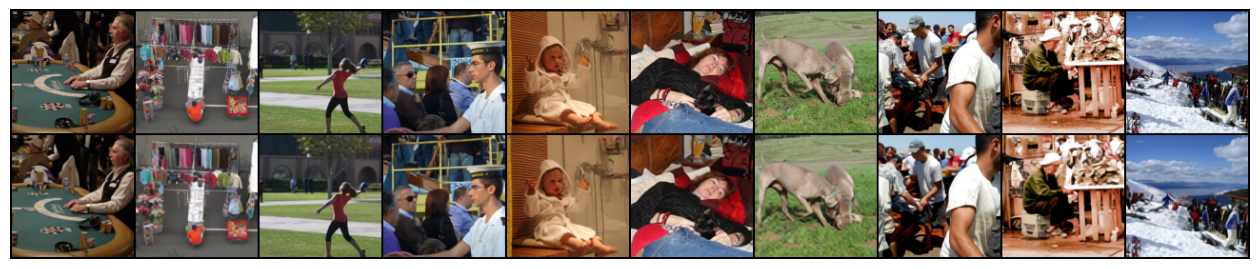

In [22]:
encoder_ema = VAEEncoder().to('cuda')
decoder_mae = VAEDecoder().to('cuda')
ckpt = torch.load('model_weights/best_vae.pt')
encoder_ema.load_state_dict(ckpt['encoder_ema'])
decoder_mae.load_state_dict(ckpt['decoder_ema'])
import matplotlib.pyplot as plt
def reconstruct(encoder, decoder, val_loader, device, n_images=8, save_path=None):
    encoder.eval()
    decoder.eval()
    x = next(iter(val_loader))[3: 3+n_images].to(device)
    with torch.no_grad():
        mu, logvar = encoder(x)
        z = reparameterize(mu, logvar)
        x_recon = decoder(z)

    orig = (x*0.5 + 0.5).clamp(0, 1)
    recon = (x_recon*0.5 + 0.5).clamp(0, 1)
    comparasion = torch.cat([orig, recon], dim=0)
    grid = torchvision.utils.make_grid(comparasion, nrow=n_images)
    plt.figure(figsize=(16, 6))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.show()
    return orig, recon

orig, recon = reconstruct(encoder_ema, decoder_mae, val_loader, 'cuda', n_images=10)

In [16]:
def parse_flickr_captions(captions_file):
    captions_by_image = defaultdict(list)
    line_re = re.compile(r'^(\S+)#\d+\t(.+)$')
 
    with open(captions_file, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            m = line_re.match(line)
            if not m:
                continue
            filename, caption = m.group(1), m.group(2)
            captions_by_image[filename].append(caption)
 
    return dict(captions_by_image)

class ImageOnlyDataset(Dataset):
    def __init__(self, image_dir, filenames, image_size=128):
        self.image_dir = image_dir
        self.filenames = filenames
        self.transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ])
 
    def __len__(self):
        return len(self.filenames)
 
    def __getitem__(self, idx):
        filename = self.filenames[idx]
        img = Image.open(os.path.join(self.image_dir, filename)).convert('RGB')
        return filename, self.transform(img)


@torch.no_grad()
def cache_latents(image_dir, vae_checkpoint_path, output_dir, device,
                   image_size=128, batch_size=64):
    
    os.makedirs(output_dir, exist_ok=True)
 
    encoder = VAEEncoder(latent_channels=4).to(device)
    ckpt = torch.load(vae_checkpoint_path, map_location=device)
    encoder.load_state_dict(ckpt['encoder'])
    encoder.eval()
 
    filenames = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    dataset = ImageOnlyDataset(image_dir, filenames, image_size=image_size)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
 
    for filenames_batch, images in tqdm(loader, desc="caching latents"):
        images = images.to(device)
        mu, _ = encoder(images)  # (B, 4, H/4, W/4)
        for fname, latent in zip(filenames_batch, mu.cpu()):
            torch.save(latent, os.path.join(output_dir, f"{fname}.pt"))
 
    print(f"cached {len(filenames)} latents to {output_dir}")


def compute_latent_scale(latent_dir, output_path, sample_size=2000):
    files = [f for f in os.listdir(latent_dir) if f.endswith('.pt')]
    sample_files = files[:sample_size] if len(files) > sample_size else files
 
    all_latents = torch.stack([torch.load(os.path.join(latent_dir, f)) for f in sample_files])
    std = all_latents.std().item()
    scale = 1.0 / std
 
    with open(output_path, 'w') as f:
        json.dump({'std': std, 'scale_factor': scale, 'n_samples': len(sample_files)}, f, indent=2)
 
    print(f"latent std: {std:.4f}, scale_factor: {scale:.4f} (from {len(sample_files)} samples)")
   



In [24]:
class ClipTokenEmbedder(nn.Module):
    def __init__(self, model_name='ViT-B-32', pretrained='laion2b_s34b_b79k'):
        super().__init__()
        model, _, _ = open_clip.create_model_and_transforms(model_name, pretrained=pretrained)
        self.tokenizer = open_clip.get_tokenizer(model_name)
 
        self.token_embedding = model.token_embedding
        self.positional_embedding = model.positional_embedding
        self.transformer = model.transformer
        self.ln_final = model.ln_final
        self.attn_mask = model.attn_mask
        self.context_length = model.context_length
        self.width = model.transformer.width
 
        for p in self.parameters():
            p.requires_grad = False
        self.eval()
 
    @torch.no_grad()
    def forward(self, texts, device):
        tokens = self.tokenizer(texts).to(device) 
 
        x = self.token_embedding(tokens)                       
        x = x + self.positional_embedding.to(x.dtype)
        x = self.transformer(x, attn_mask=self.attn_mask.to(device))
        x = self.ln_final(x)                                  
 
        return x, tokens

@torch.no_grad()
def cache_text_embeddings(captions_by_image, output_dir, device=None,
                           model_name='ViT-B-32', pretrained='laion2b_s34b_b79k',
                           batch_size=128):
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    os.makedirs(output_dir, exist_ok=True)
 
    embedder = ClipTokenEmbedder(model_name=model_name, pretrained=pretrained).to(device)
 
    flat = []
    for filename, captions in captions_by_image.items():
        for i, caption in enumerate(captions):
            flat.append((filename, i, caption))
 
    for start in tqdm(range(0, len(flat), batch_size), desc="caching text embeddings"):
        batch = flat[start:start + batch_size]
        texts = [b[2] for b in batch]
        embeddings, _ = embedder(texts, device) 
        
 
        embeddings = embeddings.cpu()

        for (filename, cap_idx, _), emb in zip(batch, embeddings):
            emb = emb.detach().cpu().clone()

            path = os.path.join(
                output_dir,
                f"{filename}__cap{cap_idx}.pt"
            )

            torch.save(emb, path)
 
    print(f"cached {len(flat)} text embeddings to {output_dir}")



In [ ]:
import os
import csv
import json
import torch
from collections import defaultdict
from tqdm import tqdm

def parse_captions_csv(captions_file):
    captions_by_image = defaultdict(list)
    
    if not os.path.exists(captions_file):
        raise FileNotFoundError(f"Файл не найден: {captions_file}")
    
    with open(captions_file, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)

        try:
            header = next(reader)
            print(f"Заголовок: {header}")
        except StopIteration:
            print("⚠️ Файл пуст!")
            return {}
        
        if header != ['image', 'caption'] and header != ['image', 'caption']:
            print(f"⚠️ Заголовок '{header}' не соответствует ожидаемому 'image,caption'")
            f.seek(0)
            reader = csv.reader(f)
            f.seek(0)
            reader = csv.reader(f)
            first_row = next(reader)
            if first_row[0] == 'image' or first_row[0] == '1000092795.jpg':
                print(f"Пропускаем первую строку: {first_row}")
            else:
                f.seek(0)
                reader = csv.reader(f)
        
        for row in reader:
            if not row:
                continue
            if len(row) < 2:
                continue
            
            filename = row[0].strip()
            caption = row[1].strip()
            if caption.startswith('"') and caption.endswith('"'):
                caption = caption[1:-1]
            
            captions_by_image[filename].append(caption)
    
    return dict(captions_by_image)

try:
    captions = parse_captions_csv('data/captions.txt')
except FileNotFoundError as e:
    print(f"❌ {e}")
    exit(1)

print(f"✅ Распарсено {len(captions)} изображений")
print(f"✅ Всего подписей: {sum(len(v) for v in captions.values())}")

with open('captions.json', 'w', encoding='utf-8') as f:
    json.dump(captions, f, ensure_ascii=False, indent=2)

print("✅ Сохранено в captions.json")


Заголовок: ['image', 'caption']
✅ Распарсено 31783 изображений
✅ Всего подписей: 158915
✅ Сохранено в captions.json

📷 1000092795.jpg
  1: Two young guys with shaggy hair look at their hands while hanging out in the yard .
  2: Two young , White males are outside near many bushes .
  ... и еще 3 подписей

📷 10002456.jpg
  1: Several men in hard hats are operating a giant pulley system .
  2: Workers look down from up above on a piece of equipment .
  ... и еще 3 подписей

📷 1000268201.jpg
  1: A child in a pink dress is climbing up a set of stairs in an entry way .
  2: A little girl in a pink dress going into a wooden cabin .
  ... и еще 3 подписей

⏳ Кэшируем текстовые эмбеддинги...


caching text embeddings:   4%|▎         | 45/1242 [04:28<1:59:04,  5.97s/it]


KeyboardInterrupt: 

In [25]:
import json

# 1️⃣ Загружаем словарь из JSON
with open('captions.json', 'r', encoding='utf-8') as f:
    captions = json.load(f)  # ← теперь это словарь

# 2️⃣ Передаем словарь
cache_text_embeddings(captions, 'cache/text_embeddings')

caching text embeddings: 100%|██████████| 1242/1242 [06:22<00:00,  3.25it/s]

cached 158915 text embeddings to cache/text_embeddings


In [ ]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
 
    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half_dim, device=device).float() / half_dim
        )
        args = t.float()[:, None] * freqs[None, :]
        embedding = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if self.dim % 2 == 1:
            embedding = F.pad(embedding, (0, 1))
        return embedding

class TimeEmbeddingMLP(nn.Module):
    def __init__(self, dim, time_embed_dim):
        super().__init__()
        self.sinusoidal = SinusoidalTimeEmbedding(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, time_embed_dim),
            nn.SiLU(),
            nn.Linear(time_embed_dim, time_embed_dim),
        )
 
    def forward(self, t):
        return self.mlp(self.sinusoidal(t))


class ResBlockTime(nn.Module):
    def __init__(self, in_ch, out_ch, time_embed_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
 
        self.time_proj = nn.Linear(time_embed_dim, out_ch)
 
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
 
        self.skip = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()
 
    def forward(self, x, time_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_proj(time_emb)[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class CrossAttentionBlock(nn.Module):
    def __init__(self, channels, context_dim, num_heads=8):
        super().__init__()
        self.norm_in = nn.GroupNorm(8, channels)
        self.proj_in = nn.Conv2d(channels, channels, kernel_size=1)
 
        self.num_heads = num_heads
        self.head_dim = channels // num_heads
 
        self.norm_self = nn.LayerNorm(channels)
        self.self_attn = nn.MultiheadAttention(channels, num_heads, batch_first=True)
 
        self.norm_cross = nn.LayerNorm(channels)
        self.to_q = nn.Linear(channels, channels)
        self.to_k = nn.Linear(context_dim, channels)
        self.to_v = nn.Linear(context_dim, channels)
        self.cross_out = nn.Linear(channels, channels)
 
        self.norm_ff = nn.LayerNorm(channels)
        self.ff = nn.Sequential(
            nn.Linear(channels, channels * 4),
            nn.GELU(),
            nn.Linear(channels * 4, channels),
        )
 
        self.proj_out = nn.Conv2d(channels, channels, kernel_size=1)
 
    def forward(self, x, context):
        b, c, h, w = x.shape
        residual = x
 
        x = self.proj_in(self.norm_in(x))
        x = x.reshape(b, c, h * w).permute(0, 2, 1)
 
        x = x + self.self_attn(self.norm_self(x), self.norm_self(x), self.norm_self(x))[0]
 
        x_norm = self.norm_cross(x)
        q = self.to_q(x_norm)
        k = self.to_k(context)
        v = self.to_v(context)
 
        q = q.reshape(b, -1, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.reshape(b, -1, self.num_heads, self.head_dim).transpose(1, 2)  
        v = v.reshape(b, -1, self.num_heads, self.head_dim).transpose(1, 2)
 
        attn = torch.softmax(q @ k.transpose(-1, -2) / math.sqrt(self.head_dim), dim=-1)
        out = attn @ v 
        out = out.transpose(1, 2).reshape(b, h * w, c)
        x = x + self.cross_out(out)
 
        x = x + self.ff(self.norm_ff(x))
 
        x = x.permute(0, 2, 1).reshape(b, c, h, w)
        return self.proj_out(x) + residual



In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels=4, base_ch=128, context_dim=512,
                 num_res_blocks=2, num_heads=8):
        super().__init__()
        time_embed_dim = base_ch * 4
        self.time_embed = TimeEmbeddingMLP(base_ch, time_embed_dim)
 
        self.in_conv = nn.Conv2d(in_channels, base_ch, kernel_size=3, padding=1)
 
        self.down0 = nn.ModuleList([
            ResBlockTime(base_ch, base_ch, time_embed_dim) for _ in range(num_res_blocks)
        ])
        self.downsample0 = Downsample(base_ch)
 
        ch1 = base_ch * 2
        self.down1_res = nn.ModuleList([
            ResBlockTime(base_ch if i == 0 else ch1, ch1, time_embed_dim) for i in range(num_res_blocks)
        ])
        self.down1_attn = nn.ModuleList([
            CrossAttentionBlock(ch1, context_dim, num_heads) for _ in range(num_res_blocks)
        ])
        self.downsample1 = Downsample(ch1)
 
        ch2 = base_ch * 4
        self.down2_res = nn.ModuleList([
            ResBlockTime(ch1 if i == 0 else ch2, ch2, time_embed_dim) for i in range(num_res_blocks)
        ])
        self.down2_attn = nn.ModuleList([
            CrossAttentionBlock(ch2, context_dim, num_heads) for _ in range(num_res_blocks)
        ])
 
        self.mid_res1 = ResBlockTime(ch2, ch2, time_embed_dim)
        self.mid_attn = CrossAttentionBlock(ch2, context_dim, num_heads)
        self.mid_res2 = ResBlockTime(ch2, ch2, time_embed_dim)
 
        self.up2_res = nn.ModuleList([
            ResBlockTime(ch2 * 2, ch2, time_embed_dim) for _ in range(num_res_blocks)
        ])
        self.up2_attn = nn.ModuleList([
            CrossAttentionBlock(ch2, context_dim, num_heads) for _ in range(num_res_blocks)
        ])
        self.upsample2 = Upsample(ch2)
        self.up2_to_ch1 = nn.Conv2d(ch2, ch1, kernel_size=1)
 
        self.up1_res = nn.ModuleList([
            ResBlockTime(ch1 * 2, ch1, time_embed_dim) for _ in range(num_res_blocks)
        ])
        self.up1_attn = nn.ModuleList([
            CrossAttentionBlock(ch1, context_dim, num_heads) for _ in range(num_res_blocks)
        ])
        self.upsample1 = Upsample(ch1)
        self.up1_to_ch0 = nn.Conv2d(ch1, base_ch, kernel_size=1)
 
        self.up0_res = nn.ModuleList([
            ResBlockTime(base_ch * 2, base_ch, time_embed_dim) for _ in range(num_res_blocks)
        ])
 
        self.norm_out = nn.GroupNorm(8, base_ch)
        self.out_conv = nn.Conv2d(base_ch, in_channels, kernel_size=3, padding=1)
 
    def forward(self, x, timesteps, context):
        
        time_emb = self.time_embed(timesteps)
 
        x = self.in_conv(x)
 
        skips = []
 
        for block in self.down0:
            x = block(x, time_emb)
            skips.append(x)
        x = self.downsample0(x)
 
        for res, attn in zip(self.down1_res, self.down1_attn):
            x = res(x, time_emb)
            x = attn(x, context)
            skips.append(x)
        x = self.downsample1(x)
 
        for res, attn in zip(self.down2_res, self.down2_attn):
            x = res(x, time_emb)
            x = attn(x, context)
            skips.append(x)
 
        x = self.mid_res1(x, time_emb)
        x = self.mid_attn(x, context)
        x = self.mid_res2(x, time_emb)
 
       
        for res, attn in zip(self.up2_res, self.up2_attn):
            x = torch.cat([x, skips.pop()], dim=1)
            x = res(x, time_emb)
            x = attn(x, context)
        x = self.up2_to_ch1(self.upsample2(x))
 
        for res, attn in zip(self.up1_res, self.up1_attn):
            x = torch.cat([x, skips.pop()], dim=1)
            x = res(x, time_emb)
            x = attn(x, context)
        x = self.up1_to_ch0(self.upsample1(x))
 
        for res in self.up0_res:
            x = torch.cat([x, skips.pop()], dim=1)
            x = res(x, time_emb)
 
        assert len(skips) == 0, "skip stack should be fully consumed"
 
        x = F.silu(self.norm_out(x))
        return self.out_conv(x)
